In [89]:
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from os.path import join, basename
import numpy as np
from scipy.ndimage import gaussian_filter, rotate

In [ ]:
# Create Gaussian kernel
def gaussian_kernel(size=21, sigma=1.0):
    x = torch.arange(size) - size//2
    y = torch.arange(size) - size//2
    X, Y = torch.meshgrid(x, y, indexing="ij")
    g = torch.exp(-(X**2 + Y**2) / (2*sigma#**2))
    return (g-g.min())/g.max()


def rotate_deltas(img: torch.Tensor, theta_deg: float):
    """
    Rotate an NCHW tensor containing sparse delta(s) by theta_deg about the image center.
    Keeps values as deltas (no interpolation). Nearest-pixel placement with center rotation.
    
    - img: (N, C, H, W) tensor
    - theta_deg: rotation in degrees
    Returns: tensor of same shape.
    """
    assert img.dim() == 4, "img must be NCHW"
    N, C, H, W = img.shape
    device, dtype = img.device, img.dtype

    out = torch.zeros_like(img)

    # center of rotation in pixel coords
    cx = (W - 1) / 2.0
    cy = (H - 1) / 2.0

    th = torch.tensor(theta_deg, device=device, dtype=dtype) * torch.pi / 180
    c, s = torch.cos(th), torch.sin(th)

    # locations of nonzeros (N, C, y, x)
    nz = (img != 0).nonzero(as_tuple=False)

    for n, cidx, y, x in nz:
        # shift to center, rotate, shift back
        xr = (x.item() - cx)
        yr = (y.item() - cy)
        x2 = xr * float(c) - yr * float(s) + cx
        y2 = xr * float(s) + yr * float(c) + cy

        # nearest integer pixel
        xi = int(round(x2))
        yi = int(round(y2))

        if 0 <= xi < W and 0 <= yi < H:
            # keep as delta; if multiple land on same pixel, keep the max value
            out[n, cidx, yi, xi] = torch.maximum(out[n, cidx, yi, xi], img[n, cidx, y, x])

    return out


def plotgrid(stack):
    num_psf = stack.shape[0]  

    ncols = 5  # 원하는대로
    nrows = (num_psf + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))

    for i in range(num_psf):
        row, col = divmod(i, ncols)
        ax = axes[row, col]
        ax.imshow(stack[i].detach().numpy(), cmap='gray')
        ax.set_title(f"Depth {i+2}")   # depth index는 2부터일 수도 있으니 맞게 조절
        ax.axis('off')

    for i in range(num_psf, nrows*ncols):
        row, col = divmod(i, ncols)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    import torch
import torch.nn.functional as F

def rot_img_center(x: torch.Tensor, theta_deg: float, mode="nearest"):
    """
    Rotate NCHW tensor x by theta_deg about the image center.
    Uses align_corners=False normalization.
    """
    assert x.dim() == 4, "x must be NCHW"
    N, C, H, W = x.shape
    device, dtype = x.device, x.dtype

    # radians
    th = torch.tensor(theta_deg, device=device, dtype=dtype) * torch.pi / 180

    c, s = torch.cos(th), torch.sin(th)
    R = torch.stack([torch.stack([c, -s]),
                     torch.stack([s,  c])])           # 2x2

    # rotate about center in *pixel* coords
    cx = (W - 1) / 2.0
    cy = (H - 1) / 2.0
    center = torch.tensor([cx, cy], device=device, dtype=dtype)  # 2,
    t_pix = center - R @ center                                   # 2,

    # convert translation to normalized coords for align_corners=False
    tx = t_pix[0] * (2.0 / W)
    ty = t_pix[1] * (2.0 / H)

    A = torch.stack([torch.stack([R[0,0], R[0,1], tx]),
                     torch.stack([R[1,0], R[1,1], ty])])          # 2x3
    A = A.unsqueeze(0).expand(N, -1, -1)                          # Nx2x3

    grid = F.affine_grid(A, x.size(), align_corners=False)
    return F.grid_sample(x, grid, mode=mode, padding_mode='zeros', align_corners=False)


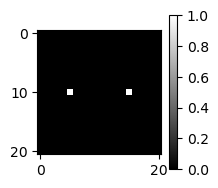

In [99]:
# parameters 
psf_size = 21
center = psf_size //2
space = 5
num_depth = 30

img = torch.zeros(1, 1, psf_size, psf_size)
img[0, 0, center, center-space] = 1.0   
img[0, 0, center, center+space] = 1.0 

plt.figure(figsize=(2,2))
plt.imshow(img.squeeze().squeeze(), cmap='gray')
plt.colorbar()
plt.show()

torch.Size([1, 1, 21, 21])


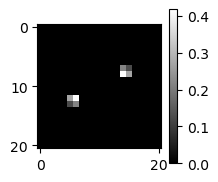

In [100]:
test = rot_img(img, 28, dtype=img.dtype)
print(test.shape)
plt.figure(figsize=(2,2))
plt.imshow(test.squeeze().squeeze(), cmap='gray')
plt.colorbar()
plt.show()

In [102]:
angles = torch.linspace(0, 90, steps = num_depth)
psf_list = []

img = torch.zeros(1, 1, psf_size, psf_size)
img[0, 0, center, center-space] = 1.0   
img[0, 0, center, center+space] = 1.0 

kernel = gaussian_kernel().unsqueeze(0).unsqueeze(0)

for theta in angles:
    #base = rot_img(img, theta, img.dtype)
    base = rotate_deltas(img, theta)
    #otated = rotate(img.numpy(), angle=float(theta), reshape=False, order=1, mode='nearest')
    conv = F.conv2d(base, kernel, padding=21//2)
    psf_list.append(torch.tensor(conv, dtype = torch.float32))
psfs = torch.stack(psf_list)
psfs = psfs.squeeze(1)  

/tmp/ipykernel_3996588/814830678.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th = torch.tensor(theta_deg, device=device, dtype=dtype) * torch.pi / 180
/tmp/ipykernel_3996588/2074181873.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psf_list.append(torch.tensor(conv, dtype = torch.float32))


In [103]:
print(psfs.shape)

torch.Size([30, 1, 21, 21])


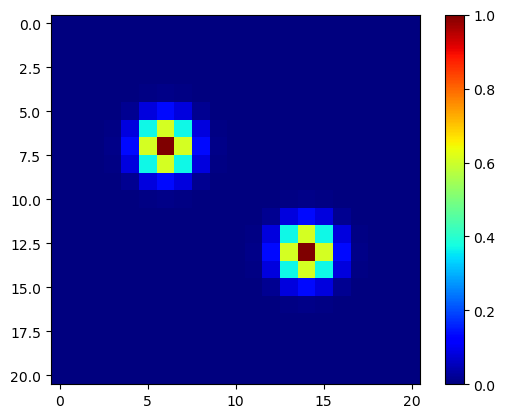

In [104]:
plt.imshow(psfs[10].squeeze().squeeze(), cmap='jet')
plt.colorbar()

(30, 1, 21, 21)


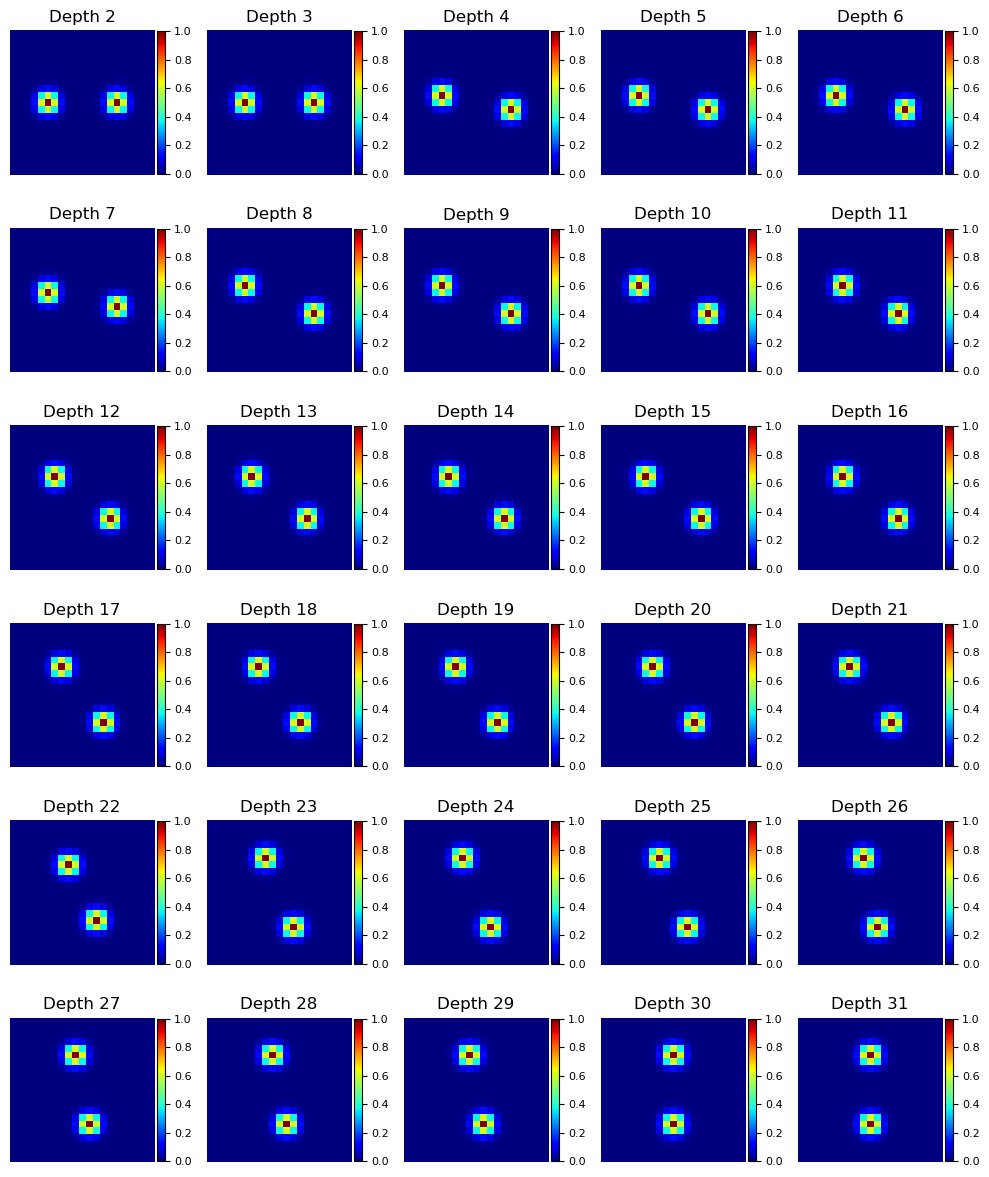

In [105]:
print(psfs.detach().numpy().shape)
psf_stack = psfs.squeeze()


num_psf = psfs.shape[0]  
ncols = 5  # 원하는대로
nrows = (num_psf + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))

for i in range(num_psf):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    im = ax.imshow(psf_stack[i].detach().numpy(), cmap='jet')
    ax.set_title(f"Depth {i+2}")   # depth index는 2부터일 수도 있으니 맞게 조절
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=8)

for i in range(num_psf, nrows*ncols):
    row, col = divmod(i, ncols)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

# Start with delta image
psf_size = 21
center = psf_size //2
space = 5

img = torch.zeros(1, 1, 21, 21)
img[0, 0, center, center-space] = 1.0   #
img[0, 0, center, center+space] = 1.0   #


# Create Gaussian kernel
def gaussian_kernel(size=21, sigma=1.0):
    x = torch.arange(size) - size//2
    y = torch.arange(size) - size//2
    X, Y = torch.meshgrid(x, y, indexing="ij")
    g = torch.exp(-(X**2 + Y**2) / (2*sigma**2))
    return (g-g.min())/g.max()

kernel = gaussian_kernel().unsqueeze(0).unsqueeze(0)

# Convolve delta image with Gaussian
img = F.conv2d(img, kernel, padding=21//2)

print(img.squeeze().squeeze().shape)
plt.imshow(img.squeeze().squeeze(), cmap='jet')
plt.colorbar()

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def get_rot_mat(theta):
    theta = torch.tensor(theta)
    return torch.tensor([[torch.cos(theta), -torch.sin(theta), 0],
                         [torch.sin(theta), torch.cos(theta), 0]])


def rot_img(x, theta, dtype):
    rot_mat = get_rot_mat(theta)[None, ...].type(dtype).repeat(x.shape[0],1,1)
    grid = F.affine_grid(rot_mat, x.size(), align_corners=False)
    x_rot = F.grid_sample(x, grid, mode='nearest', padding_mode='zeros', align_corners=False)
    return x_rot

test = rot_img(img, 30, img.dtype)
print(test.shape)
plt.imshow(test.squeeze().squeeze(), cmap='jet')
plt.colorbar()